In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

print(" Pandas:", pd.__version__)
print(" NumPy:", np.__version__)
print(" Sklearn:", sklearn.__version__)
print(" XGBoost:", xgboost.__version__)


 Pandas: 3.0.2
 NumPy: 2.4.4
 Sklearn: 1.8.0
 XGBoost: 3.2.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


#initally we have loaded the style of plot 
plt.style.use("seaborn-v0_8")
sns.set_palette('husl')


print("This step done")

This step done


In [3]:
df_data=pd.read_csv("../data/raw/secom_labels.data")
df_data.head()

,"-1 ""19/07/2008 11:55:00"""
0,"-1 ""19/07/2008 12:32:00"""
1,"1 ""19/07/2008 13:17:00"""
2,"-1 ""19/07/2008 14:43:00"""
3,"-1 ""19/07/2008 15:22:00"""
4,"-1 ""19/07/2008 17:53:00"""


In [4]:
#as i can see that data is mess no define columns

df_data=pd.read_csv("../data/raw//secom.data",sep=" ",header=None)
df_data.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [5]:
df_labels=pd.read_csv("../data/raw/secom_labels.data",sep=" ",header=None,names=["labels","time"])
df_labels.head()

,labels,time
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [6]:
print(df_data.shape)
print(df_labels.shape)

(1567, 590)
(1567, 2)


In [7]:
#lets combine both col to make single dataframe 

df_data.columns=[f'sensor_{i}'for i in range(df_data.shape[1])]

# row wise concatenate
df=pd.concat([df_data,df_labels],axis=1)

# converting timestamps format 
df["time"]=pd.to_datetime(df["time"])

C:\Users\Jatin\AppData\Local\Temp\ipykernel_27480\2261162863.py:9: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["time"]=pd.to_datetime(df["time"])


In [8]:
df

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,labels,time
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,2008-07-19 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,2008-07-19 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,2008-07-19 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 15:22:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1,2008-10-16 15:13:00
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1,2008-10-16 20:49:00
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1,2008-10-17 05:26:00
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1,2008-10-17 06:01:00


In [9]:
df.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,labels,time
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,2008-07-19 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,2008-07-19 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,2008-07-19 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 15:22:00


In [10]:
#next plan is to understand data and do eda
# understanding data 

# 1. to check size 
#2. to check missing values
#3. to check dupicate values
#4. correlation 
#5. eda analysis

In [11]:
df.to_csv("../data/processed/secom_data.csv",index=False)

In [12]:
secom_data=pd.read_csv("../data/processed/secom_data.csv")
secom_data.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,labels,time
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1,2008-07-19 11:55:00
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1,2008-07-19 12:32:00
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1,2008-07-19 13:17:00
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 14:43:00
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1,2008-07-19 15:22:00


In [13]:
#df_data['label']=df_labels['labels']
labels_counts=secom_data["labels"].value_counts()
print(f"Pass count: {labels_counts[-1]}")
print(f"Fail count: {labels_counts[1]}")

print(f"Failure Rate: {labels_counts[1]/len(secom_data)*100}")




Pass count: 1463
Fail count: 104
Failure Rate: 6.636885768985322


<Axes: xlabel='labels', ylabel='count'>

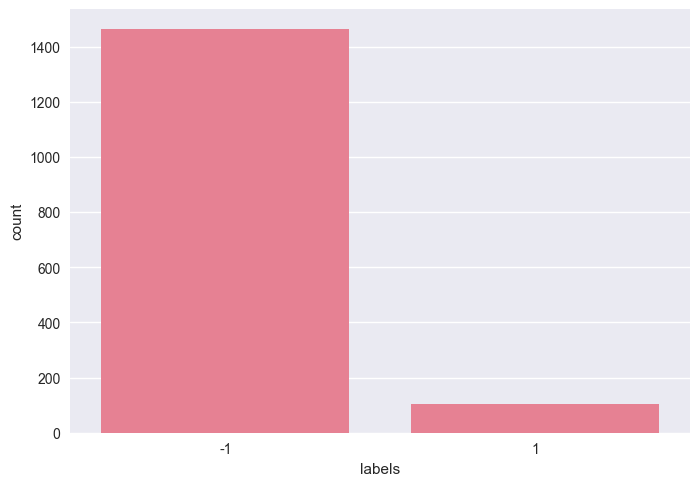

In [14]:
# out of 1567 samples 1045 pass and fail is 104 so failure rate is 
#aroud 6 percent 

sns.countplot(x="labels",data=secom_data)

([<matplotlib.patches.Wedge at 0x25003240e00>,
 [Text(-1.0761758724709176, 0.2276960507155524, '-1'),
  Text(1.0761759466636511, -0.22769570005293138, '1')],
 [Text(-0.5870050213477732, 0.12419784584484675, '93.4%'),
  Text(0.5870050618165369, -0.12419765457432619, '6.6%')])

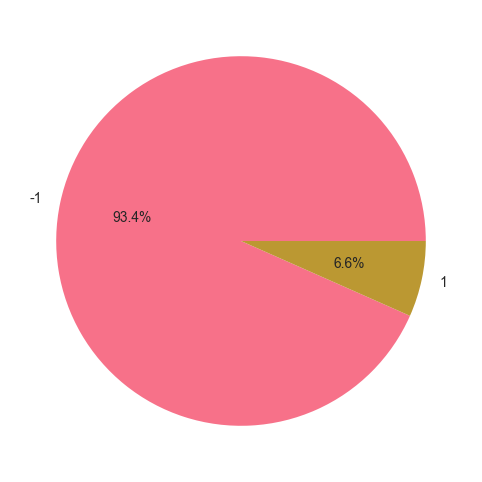

In [15]:
ax=plt.figure(figsize=(10,6))
plt.pie(labels_counts,labels=labels_counts.index,autopct="%1.1f%%")

In [16]:
#now we must compute missing values in data 

missing_values = secom_data.isnull().sum()

Features with 0% missing:   52
Features with <50% missing: 562
Features with >50% missing: 28
Features with >80% missing: 8
Features with 100% missing: 0


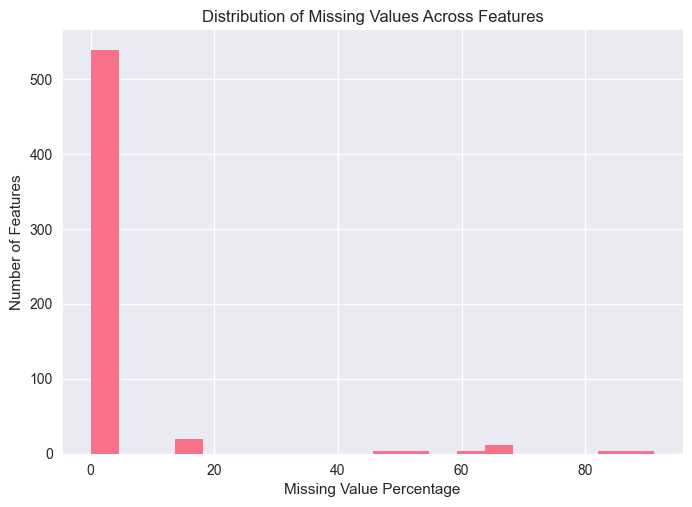

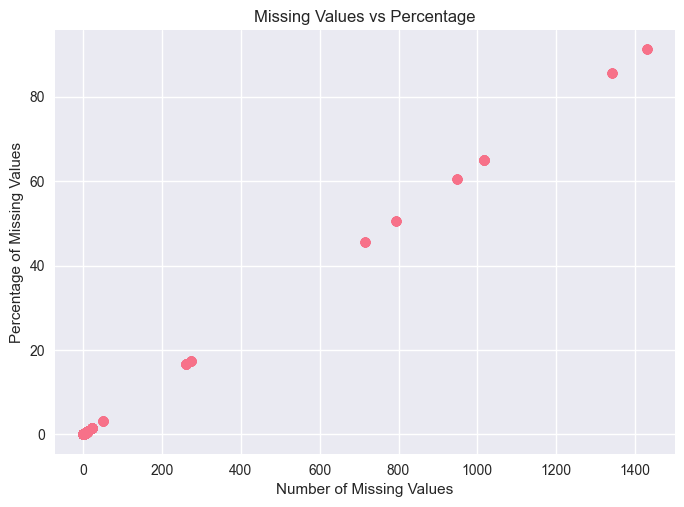

In [17]:


# ab ek kaam krte missing value ke distribution ko plot krke visulaize krte hai 


missing_values=secom_data.drop(columns=['time','labels']).isnull().sum()
missing_pct=(missing_values/secom_data.shape[0])*100


print(f"Features with 0% missing:   {(missing_pct == 0).sum()}")
print(f"Features with <50% missing: {(missing_pct < 50).sum()}")
print(f"Features with >50% missing: {(missing_pct > 50).sum()}")
print(f"Features with >80% missing: {(missing_pct > 80).sum()}")
print(f"Features with 100% missing: {(missing_pct == 100).sum()}")



plt.hist(missing_pct,bins=20)
plt.xlabel("Missing Value Percentage")
plt.ylabel("Number of Features")
plt.title("Distribution of Missing Values Across Features")
plt.show()


plt.scatter(missing_values,missing_pct)
plt.xlabel("Number of Missing Values")
plt.ylabel("Percentage of Missing Values")
plt.title("Missing Values vs Percentage")
plt.show()

In [18]:
secom_data.shape

(1567, 592)

In [19]:

#we are understanding data of first 5 sensor 
secom_data.iloc[:,:5].describe().round(2)

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4
count,1561.00,1560.00,1553.00,1553.00,1553.00
mean,3014.45,2495.85,2200.55,1396.38,4.20
std,73.62,80.41,29.51,441.69,56.36
min,2743.24,2158.75,2060.66,0.00,0.68
25%,2966.26,2452.25,2181.04,1081.88,1.02
50%,3011.49,2499.40,2201.07,1285.21,1.32
75%,3056.65,2538.82,2218.06,1591.22,1.53
max,3356.35,2846.44,2315.27,3715.04,1114.54


In [20]:
# as hame abhi ye nhi pta konsa sensor kya baata to hum kuch zada iss data se abhi keh nhi sakte bas numerically isse dekh ya visulaize kr sakte hai 

In [21]:
sensor_cols=[col for col in secom_data.columns if col.startswith("sensor_")]

# Missing percentage har sensor ke liye
missing_pct = (secom_data[sensor_cols].isnull().sum() / len(secom_data)) * 100
missing_pct = missing_pct.sort_values(ascending=False)

# Categories mein divide karo
zero_missing    = (missing_pct == 0).sum()
low_missing     = ((missing_pct > 0) & (missing_pct <= 20)).sum()
medium_missing  = ((missing_pct > 20) & (missing_pct <= 50)).sum()
high_missing    = ((missing_pct > 50) & (missing_pct < 100)).sum()
full_missing    = (missing_pct == 100).sum()


C:\Users\Jatin\AppData\Local\Temp\ipykernel_27480\633087947.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing.index, y=top_missing.values, palette='viridis')


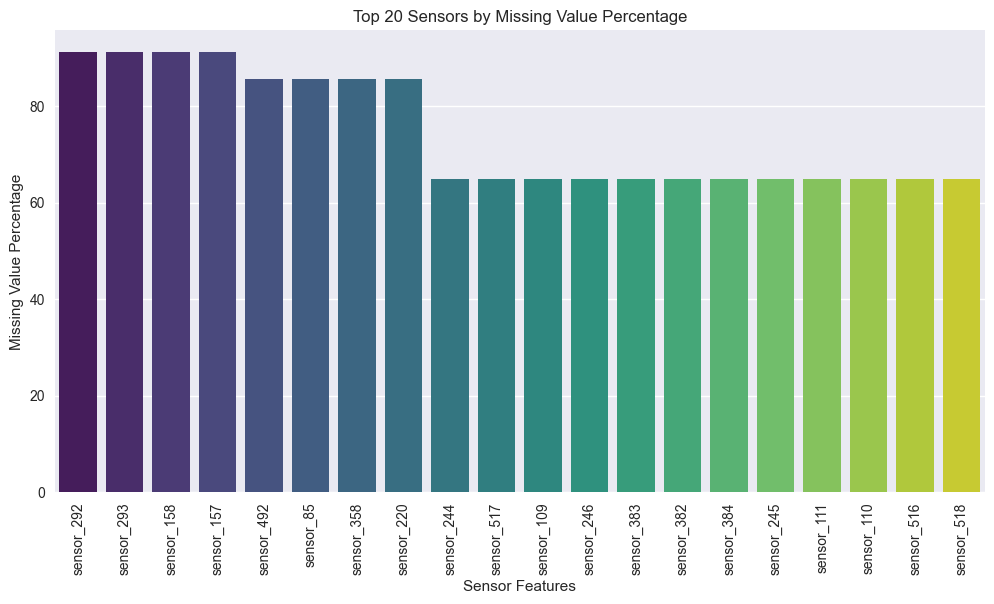

In [22]:
top_missing=missing_pct.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_missing.index, y=top_missing.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel("Sensor Features")
plt.ylabel("Missing Value Percentage")
plt.title("Top 20 Sensors by Missing Value Percentage")
plt.show()

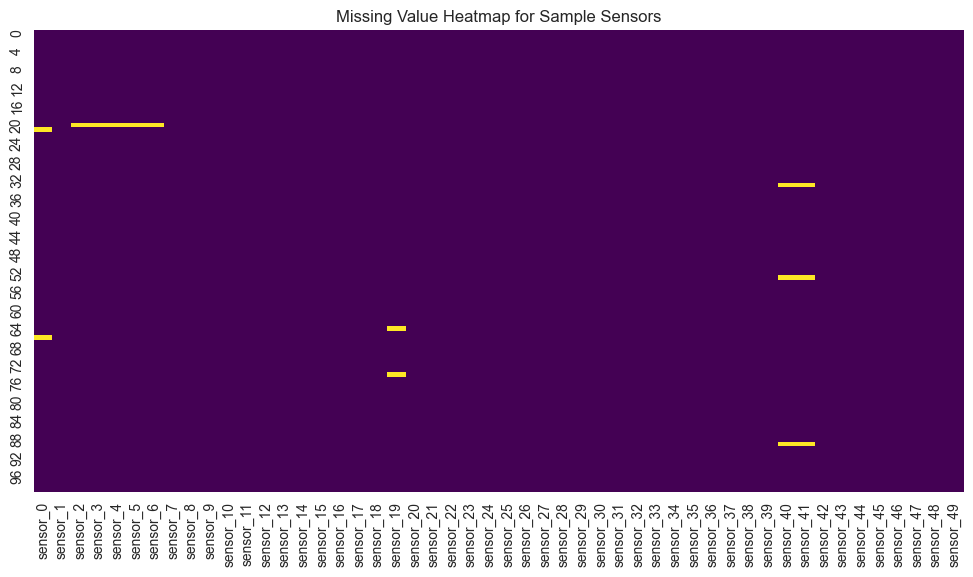

In [23]:
sample_sensors=sensor_cols[:50]
sample_df=secom_data[sample_sensors].head(100)
plt.figure(figsize=(12, 6))
sns.heatmap(sample_df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap for Sample Sensors")
plt.show()


In [24]:
#sensor_0, sensor_1, sensor_4
#teeno ka Row 16-20 pe missing hai!

#Matlab:
##→ Ek hi time pe multiple sensors band hue
#→ Kyu? Factory mein kuch hua hoga!
#   Bijli gayi? Maintenance thi?
   
#→ Yeh MCAR hai!
 #  Random event tha — sabko affect kiya





#sensor_19 → Row 64 pe missing
#sensor_40 → Row 36 pe missing
#sensor_42 → Row 92 pe missing

#Teeno alag alag time pe missing hain
#→ Koi common event nahi
#→ Individual sensor issues
#→ Yeh bhi MCAR ho sakta hai

In [25]:
""" Q1  = 25th percentile (neeche wala 25%)
Q3  = 75th percentile (upar wala 75%)
IQR = Q3 - Q1

Lower bound = Q1 - 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR

Isse bahar = OUTLIER!  """

' Q1  = 25th percentile (neeche wala 25%)\nQ3  = 75th percentile (upar wala 75%)\nIQR = Q3 - Q1\n\nLower bound = Q1 - 1.5 × IQR\nUpper bound = Q3 + 1.5 × IQR\n\nIsse bahar = OUTLIER!  '

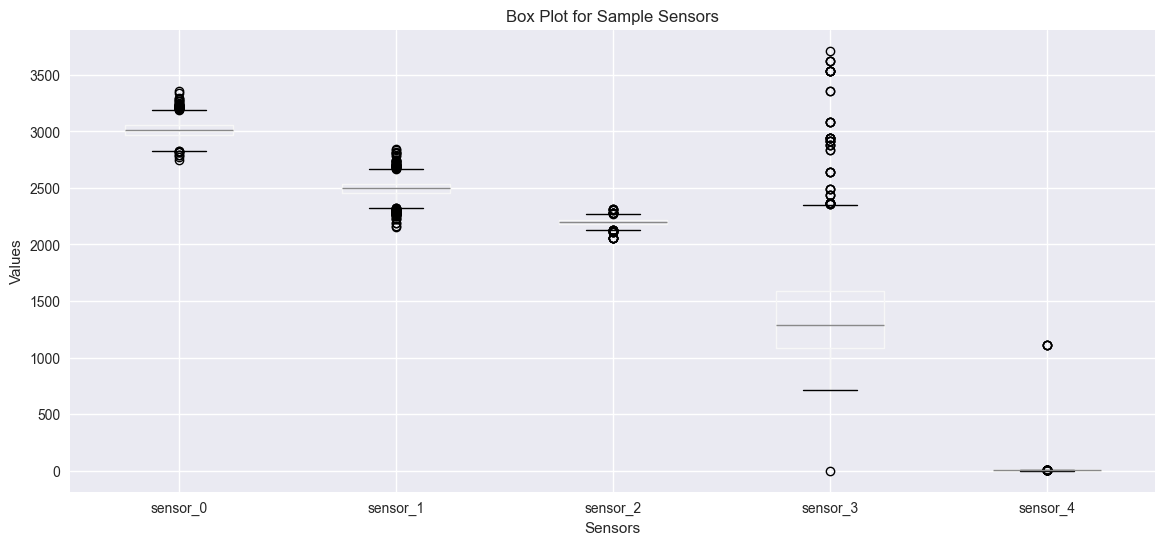

In [26]:
#we will use box plot to visulaize the outliers statistics

sample_sensors=sensor_cols[:5]

plt.figure(figsize=(14, 6))
df[sample_sensors].boxplot()
plt.title("Box Plot for Sample Sensors")
plt.xlabel("Sensors")
plt.ylabel("Values")
plt.show()

In [27]:
""" ○  ← Outlier (bahut upar)
        |
   _____|_____
  |     |     |  ← Box (IQR — middle 50% data)
  |_____|_____|
        |
        |
        ○  ← Outlier (bahut neeche)

Top line    = Q3 (75th percentile)
Middle line = Median (50th percentile)  
Bottom line = Q1 (25th percentile)
○ circles   = OUTLIERS! """

' ○  ← Outlier (bahut upar)\n        |\n   _____|_____\n  |     |     |  ← Box (IQR — middle 50% data)\n  |_____|_____|\n        |\n        |\n        ○  ← Outlier (bahut neeche)\n\nTop line    = Q3 (75th percentile)\nMiddle line = Median (50th percentile)  \nBottom line = Q1 (25th percentile)\n○ circles   = OUTLIERS! '

In [28]:
""" Box → 700 to 1400 ke beech
      (bahut bada box!)
Median → ~1250

Outliers:
→ Upar: 2400, 2900, 3000, 3600!
→ Neeche: ~0 (almost zero!)

❌ Bahut zyada variation!
❌ Outliers dono taraf hain
❌ 0 ke paas bhi ek value hai
   → Sensor malfunction? """



""" Box → 0 to 50 ke beech
      (bilkul neeche!)
Median → ~25

Outlier → 1100! 
          (baaki sab 0-50 mein
           yeh akela 1100 pe hai!)

❌ STRONG OUTLIER!
❌ 1100 clearly galat reading hai
   ya extreme condition thi """

' Box → 0 to 50 ke beech\n      (bilkul neeche!)\nMedian → ~25\n\nOutlier → 1100! \n          (baaki sab 0-50 mein\n           yeh akela 1100 pe hai!)\n\n❌ STRONG OUTLIER!\n❌ 1100 clearly galat reading hai\n   ya extreme condition thi '

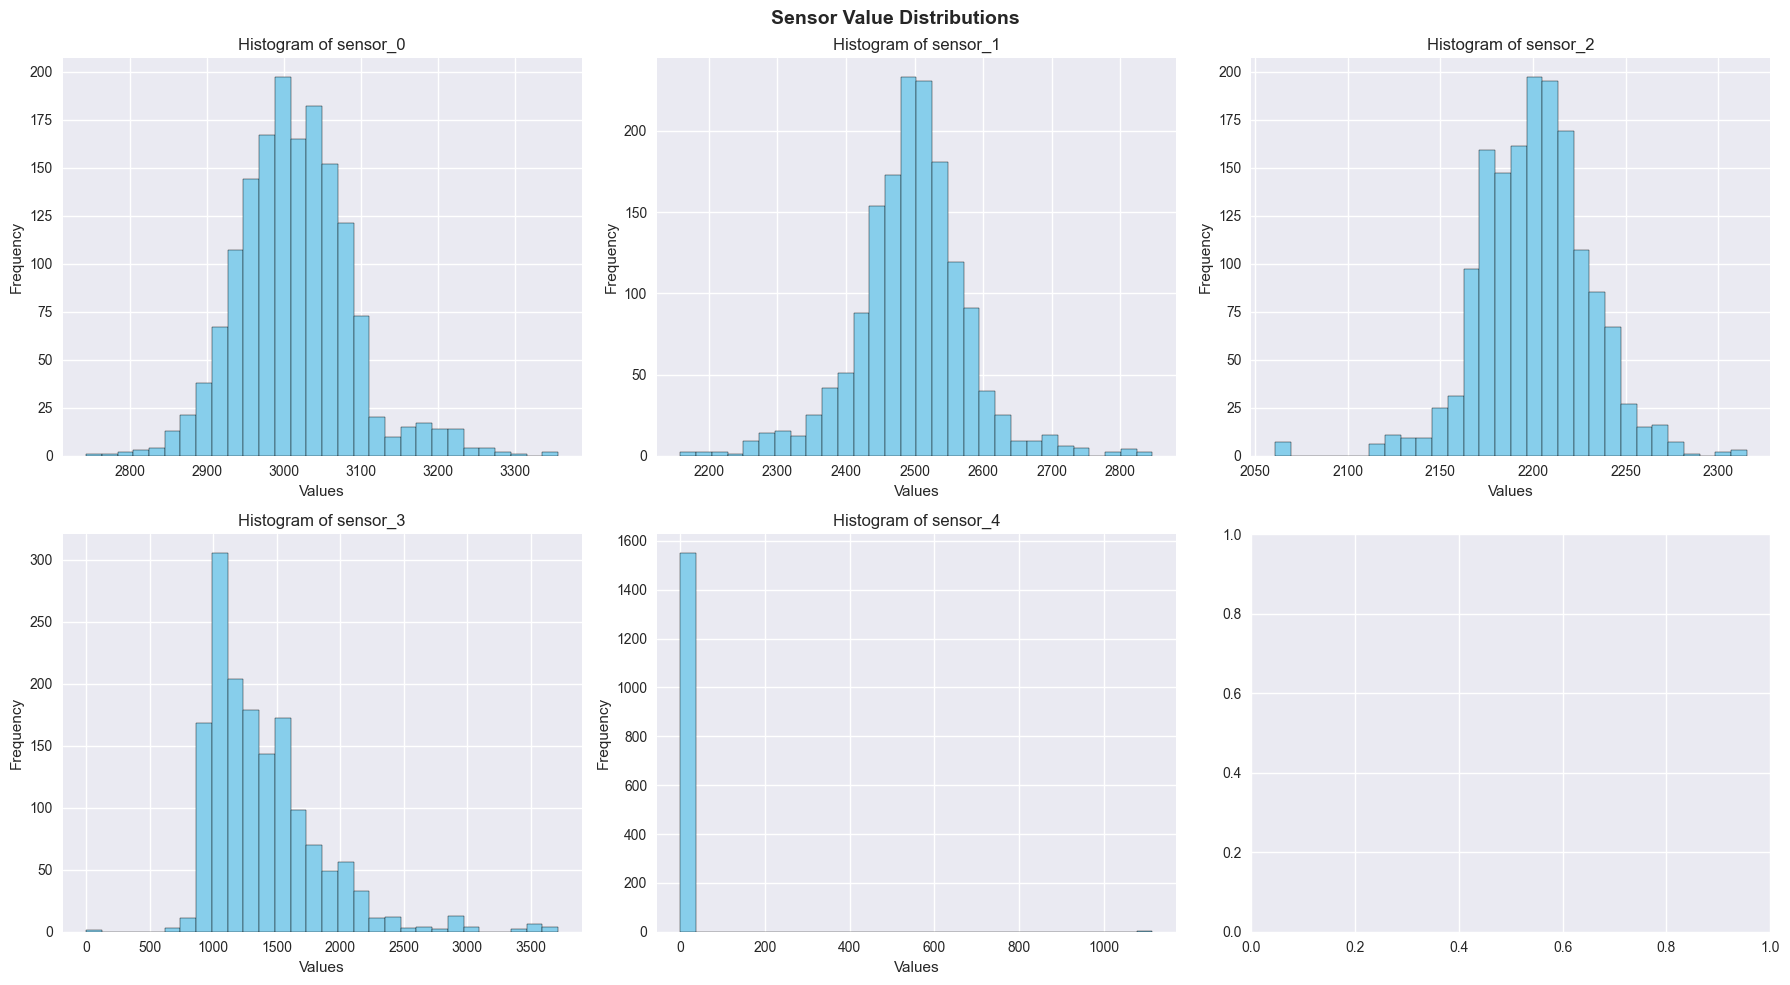

In [29]:

#5 subplot 
fig,axes=plt.subplots(2,3,figsize=(18,10))

axes=axes.flatten()

for i,sensor in enumerate(sample_sensors):
    axes[i].hist(secom_data[sensor].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f"Histogram of {sensor}")
    axes[i].set_xlabel("Values")    
    axes[i].set_ylabel("Frequency")

plt.suptitle('Sensor Value Distributions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [30]:
#senosr 3 and 4 highly skewed hai 

In [31]:
#variance is kitni average se value jaari hai agr data mei koi change nhi to variance zero hoga aur hum usse drop kr sakte hai 

#har ke column ka correlation hota dusre ke saath agr wo highly correlated hai to wo koi information nhi dega to hum usse drop kr sakte hai

""" Correlation = 2 features kitne
              saath saath move karte hain

+1.0 = Perfectly positive correlated
       (Ek badhta hai → Doosra bhi badhta hai)

-1.0 = Perfectly negative correlated
       (Ek badhta hai → Doosra ghatta hai)

0.0  = Koi relation nahi

> 0.95 = Almost same information!
         Ek DROP karo! """

' Correlation = 2 features kitne\n              saath saath move karte hain\n\n+1.0 = Perfectly positive correlated\n       (Ek badhta hai → Doosra bhi badhta hai)\n\n-1.0 = Perfectly negative correlated\n       (Ek badhta hai → Doosra ghatta hai)\n\n0.0  = Koi relation nahi\n\n> 0.95 = Almost same information!\n         Ek DROP karo! '